In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from torch.utils.data import DataLoader, TensorDataset

class ConvAutoencoder1D(nn.Module):
    def __init__(self, input_size, encoded_size):
        super(ConvAutoencoder1D, self).__init__()
        self.input_size = input_size
        self.encoded_size = encoded_size

        # Calculate the number of conv layers needed
        self.num_layers = int(math.log2(input_size // encoded_size))
        
        # Encoder
        encoder_layers = []
        in_channels = 1
        out_channels = 32
        for _ in range(self.num_layers):
            encoder_layers.append(nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=2, padding=1))
            encoder_layers.append(nn.ReLU())
            encoder_layers.append(nn.BatchNorm1d(out_channels))
            in_channels = out_channels
            out_channels = min(out_channels * 2, 128)
        encoder_layers.append(nn.Conv1d(in_channels, 1, kernel_size=3, stride=1, padding=1))
        self.encoder = nn.Sequential(*encoder_layers)

        # Decoder
        decoder_layers = []
        in_channels = 1
        out_channels = min(128, 32 * (2 ** (self.num_layers - 1)))
        for i in range(self.num_layers):
            decoder_layers.append(nn.ConvTranspose1d(in_channels, out_channels, kernel_size=3, stride=2, padding=1, output_padding=1))
            decoder_layers.append(nn.ReLU())
            encoder_layers.append(nn.BatchNorm1d(out_channels))
            in_channels = out_channels
            out_channels = max(out_channels // 2, 32)
        decoder_layers.append(nn.ConvTranspose1d(in_channels, 1, kernel_size=3, stride=1, padding=1))
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        x = x.unsqueeze(1)  # Add channel dimension
        return self.encoder(x)

    def decode(self, x):
        return self.decoder(x).squeeze(1)  # Remove channel dimension
    
    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded.squeeze(1)  # Remove channel dimension

In [69]:
class ConvAutoencoder1D3L(nn.Module):
    def __init__(self, input_size=20000, encoded_size=10000):
        super(ConvAutoencoder1D3L, self).__init__()
        self.input_size = input_size
        self.encoded_size = encoded_size
        
        # Encoder - 3 layers of conv1d, relu, batchnorm followed by final conv1d
        self.encoder = nn.Sequential(
            # Layer 1
            nn.Conv1d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            
            # Layer 2
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            
            # Layer 3
            nn.Conv1d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            
            # Final layer to reduce to encoded size
            nn.Conv1d(32, 1, kernel_size=3, stride=2, padding=1)
            # This final layer with stride=2 reduces dimension from 20000 to 10000
        )
        
        # Decoder - mirror of encoder with transposed convolutions
        self.decoder = nn.Sequential(
            # First layer to expand from encoded size
            nn.ConvTranspose1d(1, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            
            # Layer 1
            nn.ConvTranspose1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            
            # Layer 2
            nn.ConvTranspose1d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            
            # Layer 3
            nn.ConvTranspose1d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(1)
        )
    
    def encode(self, x):
        x = x.unsqueeze(1)  # Add channel dimension [batch_size, 1, 20000]
        return self.encoder(x)  # Output: [batch_size, 1, 10000]
    
    def decode(self, x):
        decoded = self.decoder(x)  # Input: [batch_size, 1, 10000], Output: [batch_size, 1, 20000]
        return decoded.squeeze(1)  # Remove channel dimension [batch_size, 20000]
    
    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded.squeeze(1)  # Remove channel dimension

In [84]:
from sklearn.datasets import make_classification

# Generate a sample classification dataset
X, y = make_classification(n_samples=1000, n_features=100, n_informative=10, n_redundant=90, random_state=1)
# X, y = make_classification(n_samples=1000, n_features=20_000, random_state=1)

# Print the shapes of the generated data
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (1000, 100)
Target vector shape: (1000,)


In [85]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=1)

In [86]:
# Scale data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [87]:
y_train.shape

(800,)

In [88]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.FloatTensor(y_train)
y_test_tensor = torch.FloatTensor(y_test)

In [89]:
# Create TensorDatasets for training and testing data
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [90]:
# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [105]:
input_size = X.shape[1]
# model = ConvAutoencoder1D3L(input_size, input_size // 2)
model = ConvAutoencoder1D(input_size, input_size // 2)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [106]:
model

ConvAutoencoder1D(
  (encoder): Sequential(
    (0): Conv1d(1, 32, kernel_size=(3,), stride=(2,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv1d(32, 1, kernel_size=(3,), stride=(1,), padding=(1,))
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(1, 32, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
    (1): ReLU()
    (2): ConvTranspose1d(32, 1, kernel_size=(3,), stride=(1,), padding=(1,))
  )
)

In [107]:
import numpy as np
import matplotlib.pyplot as plt

# Training and testing loop
epochs = 100
train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        inputs = batch[0].squeeze(1)
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for batch in test_loader:
            inputs = batch[0].squeeze(1)
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            test_loss += loss.item()
    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

Epoch [1/100], Train Loss: 0.2882, Test Loss: 0.1396
Epoch [2/100], Train Loss: 0.0876, Test Loss: 0.0359
Epoch [3/100], Train Loss: 0.0275, Test Loss: 0.0193
Epoch [4/100], Train Loss: 0.0174, Test Loss: 0.0165
Epoch [5/100], Train Loss: 0.0152, Test Loss: 0.0152
Epoch [6/100], Train Loss: 0.0141, Test Loss: 0.0144
Epoch [7/100], Train Loss: 0.0136, Test Loss: 0.0140
Epoch [8/100], Train Loss: 0.0133, Test Loss: 0.0137
Epoch [9/100], Train Loss: 0.0131, Test Loss: 0.0135
Epoch [10/100], Train Loss: 0.0129, Test Loss: 0.0133
Epoch [11/100], Train Loss: 0.0127, Test Loss: 0.0132
Epoch [12/100], Train Loss: 0.0126, Test Loss: 0.0130
Epoch [13/100], Train Loss: 0.0124, Test Loss: 0.0130
Epoch [14/100], Train Loss: 0.0123, Test Loss: 0.0128
Epoch [15/100], Train Loss: 0.0122, Test Loss: 0.0127
Epoch [16/100], Train Loss: 0.0121, Test Loss: 0.0126
Epoch [17/100], Train Loss: 0.0120, Test Loss: 0.0125
Epoch [18/100], Train Loss: 0.0120, Test Loss: 0.0124
Epoch [19/100], Train Loss: 0.0118, T

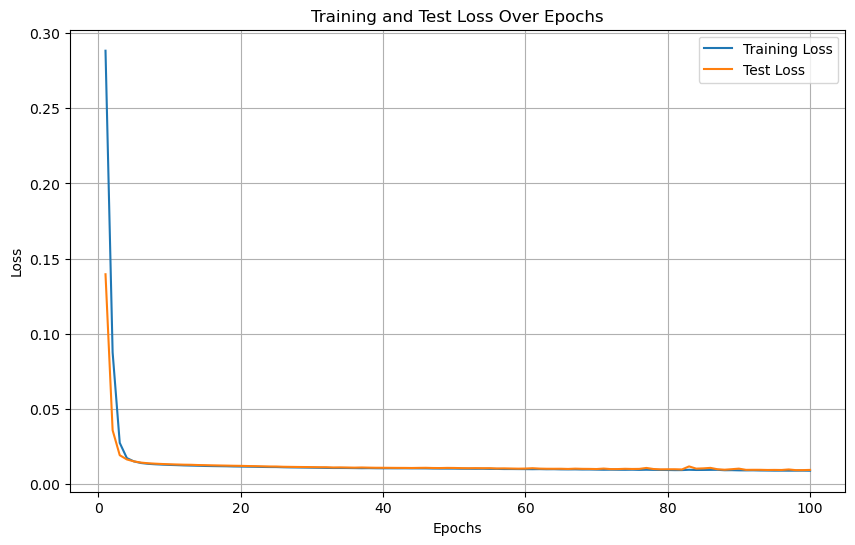

In [108]:
# Plot the training and test loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
plt.plot(range(1, epochs+1), test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [109]:
model.eval()
with torch.no_grad():
    X_train_encoded = model.encode(X_train_tensor).numpy()
    X_test_encoded = model.encode(X_test_tensor).numpy()

In [110]:
X_train.shape

(800, 100)

In [111]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(800, 1, 50)
(200, 1, 50)


# Test the classification performance

## Original Data

In [112]:
print(X_train.shape)
print(X_train_encoded.shape)

(800, 100)
(800, 1, 50)


In [113]:
# Train logistic regression
clf = LogisticRegression()
clf.fit(X_train, y_train)

LogisticRegression()

In [114]:
# Make predictions
y_pred = clf.predict(X_test)

In [115]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Classification Accuracy: {accuracy:.4f}')

Classification Accuracy: 0.8950


## Encoded Data

In [116]:
# Train logistic regression
clf2 = LogisticRegression()
clf2.fit(X_train_encoded.squeeze(1), y_train)

LogisticRegression()

In [117]:
# Make predictions
y_pred2 = clf2.predict(X_test_encoded.squeeze(1))

In [118]:
# Calculate accuracy
accuracy2 = accuracy_score(y_test, y_pred2)
print(f'Classification Accuracy: {accuracy2:.4f}')

Classification Accuracy: 0.9000
